# AutoEncoder : compression, espace latent et generation

In [1]:
from src.dataset import load_mnist_dataset, load_shapes_npz
from src.autoencoder import AutoEncoder
from src.helper import extract_full_dataset, get_device
from src.metrics import compression_report, Latent

import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt

np.random.seed(0)
torch.manual_seed(0)

print("device:", get_device())


EPOCHS = 40
EPOCHS_SWEEP = 40
BATCH_SIZE = 128

device: cuda


In [ ]:
from src.viz import (
    finish_figure,
    show_image_grid,
    show_labeled_image_rows,
    plot_latent_scatter,
    print_compression_report,
    sample_gaussian_latent,
    generate_from_latent_using_gaussian,
    interpolate_latent,
    subsample_dataset,
)


def note(**kw):
    return "fixe: " + " | ".join(f"{k}={v}" for k, v in kw.items())


def run_experiment(X_train, X_eval, input_dim, latent_dim, activation, epochs,
                   loss_function=nn.MSELoss, latent_activation=None,
                   output_activation=nn.Sigmoid, n_layers=3, learning_rate=1e-3):
    model = AutoEncoder(
        input_dim=input_dim, output_dim=input_dim, latent_dim=latent_dim,
        encoder_layer_num=n_layers, decoder_layer_num=n_layers,
        encoder_activation_function=activation, loss_function=loss_function,
        latent_activation_function=latent_activation,
        output_activation_function=output_activation,
    )
    model.fit(X_train, epochs=epochs, batch_size=BATCH_SIZE, learning_rate=learning_rate)
    latent = model.encode(X_eval)
    reconstruction = model.decode(latent)
    report = compression_report(model.get_codebook(), latent, X_eval, reconstruction)
    return {"model": model, "latent": latent, "reconstruction": reconstruction, "report": report}

## Partie A - MNIST DIGITS

In [3]:
mnist_train_images, mnist_train_labels = extract_full_dataset(load_mnist_dataset(train=True, shuffle=False))
mnist_eval_images, mnist_eval_labels = extract_full_dataset(load_mnist_dataset(train=False, shuffle=False))

MNIST_SHAPE = (1, 28, 28)
X_mnist_train, y_mnist_train = subsample_dataset(
    mnist_train_images.reshape(len(mnist_train_images), -1).numpy(), mnist_train_labels.numpy(), 15000
    )
X_mnist_eval, y_mnist_eval = subsample_dataset(
    mnist_eval_images.reshape(len(mnist_eval_images), -1).numpy(), mnist_eval_labels.numpy(), 3000
    )
print("train:", X_mnist_train.shape, "| eval:", X_mnist_eval.shape)

train: (15000, 784) | eval: (3000, 784)


### Train - ReLu et MSE comme baseline

Encoder(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=107, bias=True)
    (1): ReLU()
    (2): Linear(in_features=107, out_features=14, bias=True)
    (3): ReLU()
    (4): Linear(in_features=14, out_features=2, bias=True)
  )
)


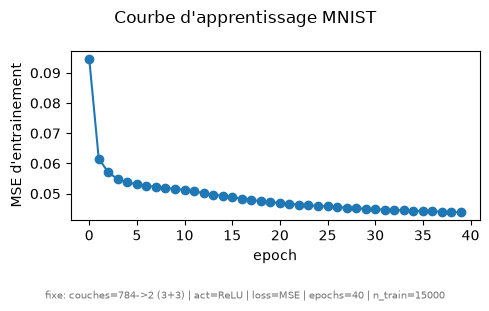

In [ ]:
mnist_model = AutoEncoder(
    input_dim=784, output_dim=784, latent_dim=2,
    encoder_layer_num=3, decoder_layer_num=3,
    encoder_activation_function=nn.ReLU, loss_function=nn.MSELoss,
)
mnist_model.fit(X_mnist_train, epochs=EPOCHS, batch_size=BATCH_SIZE)

print(mnist_model.encoder)

BASE = note(couches="784->2->784 (3 encodeur+3 decodeur)", act="ReLU", loss="MSE", epochs=EPOCHS, n_train=len(X_mnist_train))

fig = plt.figure(figsize=(5, 3))
plt.plot(mnist_model.loss_history, marker="o")
plt.xlabel("epoch"); plt.ylabel("MSE d'entrainement")
finish_figure(fig, "Courbe d'apprentissage MNIST", BASE)

### Compression et decompression

code latent par image: 2 valeurs | nature: continuous


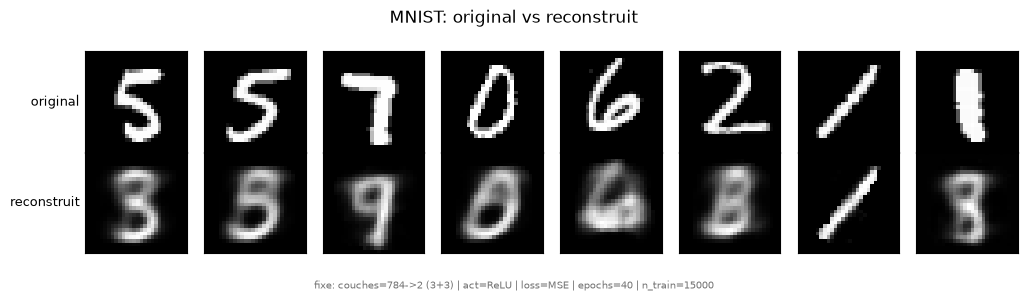

In [5]:
mnist_latent = mnist_model.encode(X_mnist_eval)
mnist_reconstructed = mnist_model.decode(mnist_latent)
print("code latent par image:", mnist_latent.array.shape[1], "valeurs | nature:", mnist_latent.nature)

show_labeled_image_rows(
    [X_mnist_eval, mnist_reconstructed], MNIST_SHAPE, ["original", "reconstruit"], n=8,
    title="MNIST: original vs reconstruit", config=BASE,
)

### Qualite de reconstruction et taille du message

In [6]:
mnist_report = compression_report(mnist_model.get_codebook(), mnist_latent, X_mnist_eval, mnist_reconstructed)
print_compression_report(mnist_report)

per_image_bytes = mnist_latent.n_bytes / len(X_mnist_eval)
print(f"\nMessage transmis par image: {per_image_bytes:.0f} octets ({mnist_latent.array.shape[1]} float32),")
print(f"contre {X_mnist_eval[0].nbytes} octets pour l'image originale en float32.")
print(f"Codebook (poids du decodeur): {mnist_report['codebook_bytes']:,} octets, partage une seule fois.")

           latent_nature: continuous
          codebook_bytes: 345276
            latent_bytes: 24000
  total_compressed_bytes: 369276
          original_bytes: 9408000
       compression_ratio: 25.4769
      reconstruction_mse: 0.0439

Message transmis par image: 8 octets (2 float32),
contre 3136 octets pour l'image originale en float32.
Codebook (poids du decodeur): 345,276 octets, partage une seule fois.


### Visualisation de l'espace latent

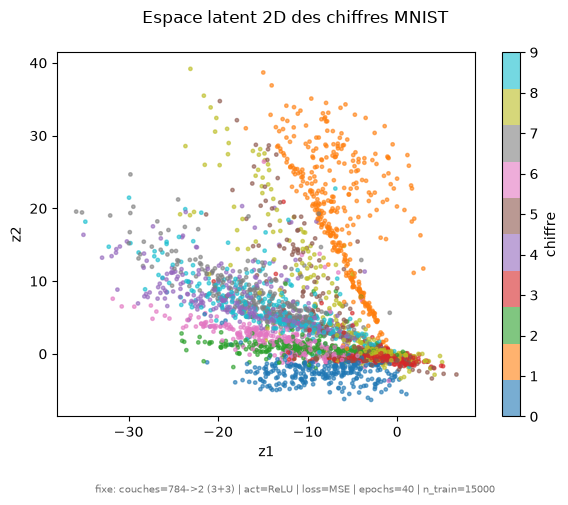

In [7]:
plot_latent_scatter(mnist_latent.array, y_mnist_eval,
                    title="Espace latent 2D des chiffres MNIST",
                    config=BASE)

### Generation de nouvelles images

Le decodeur seul est un generateur: on lui donne des codes inedits. Trois facons d'en fabriquer:
une gaussienne ajustee sur les codes observes, une droite entre deux codes reels, ou une grille
reguliere du plan latent.

Rien n'oblige les codes d'un AutoEncoder a suivre une loi connue: plus on s'eloigne des codes
reels, plus le decodeur extrapole dans une zone ou il n'a jamais ete entraine.

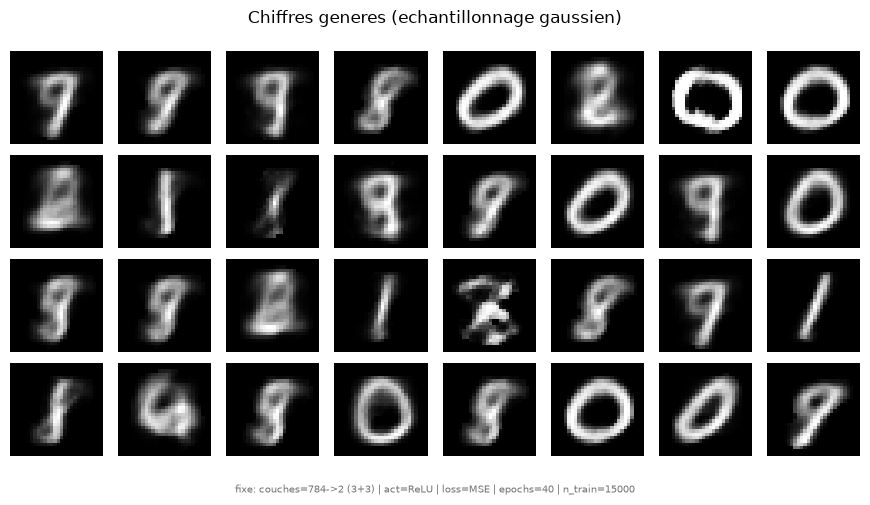

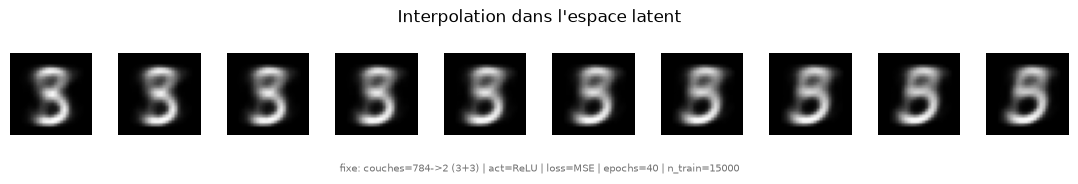

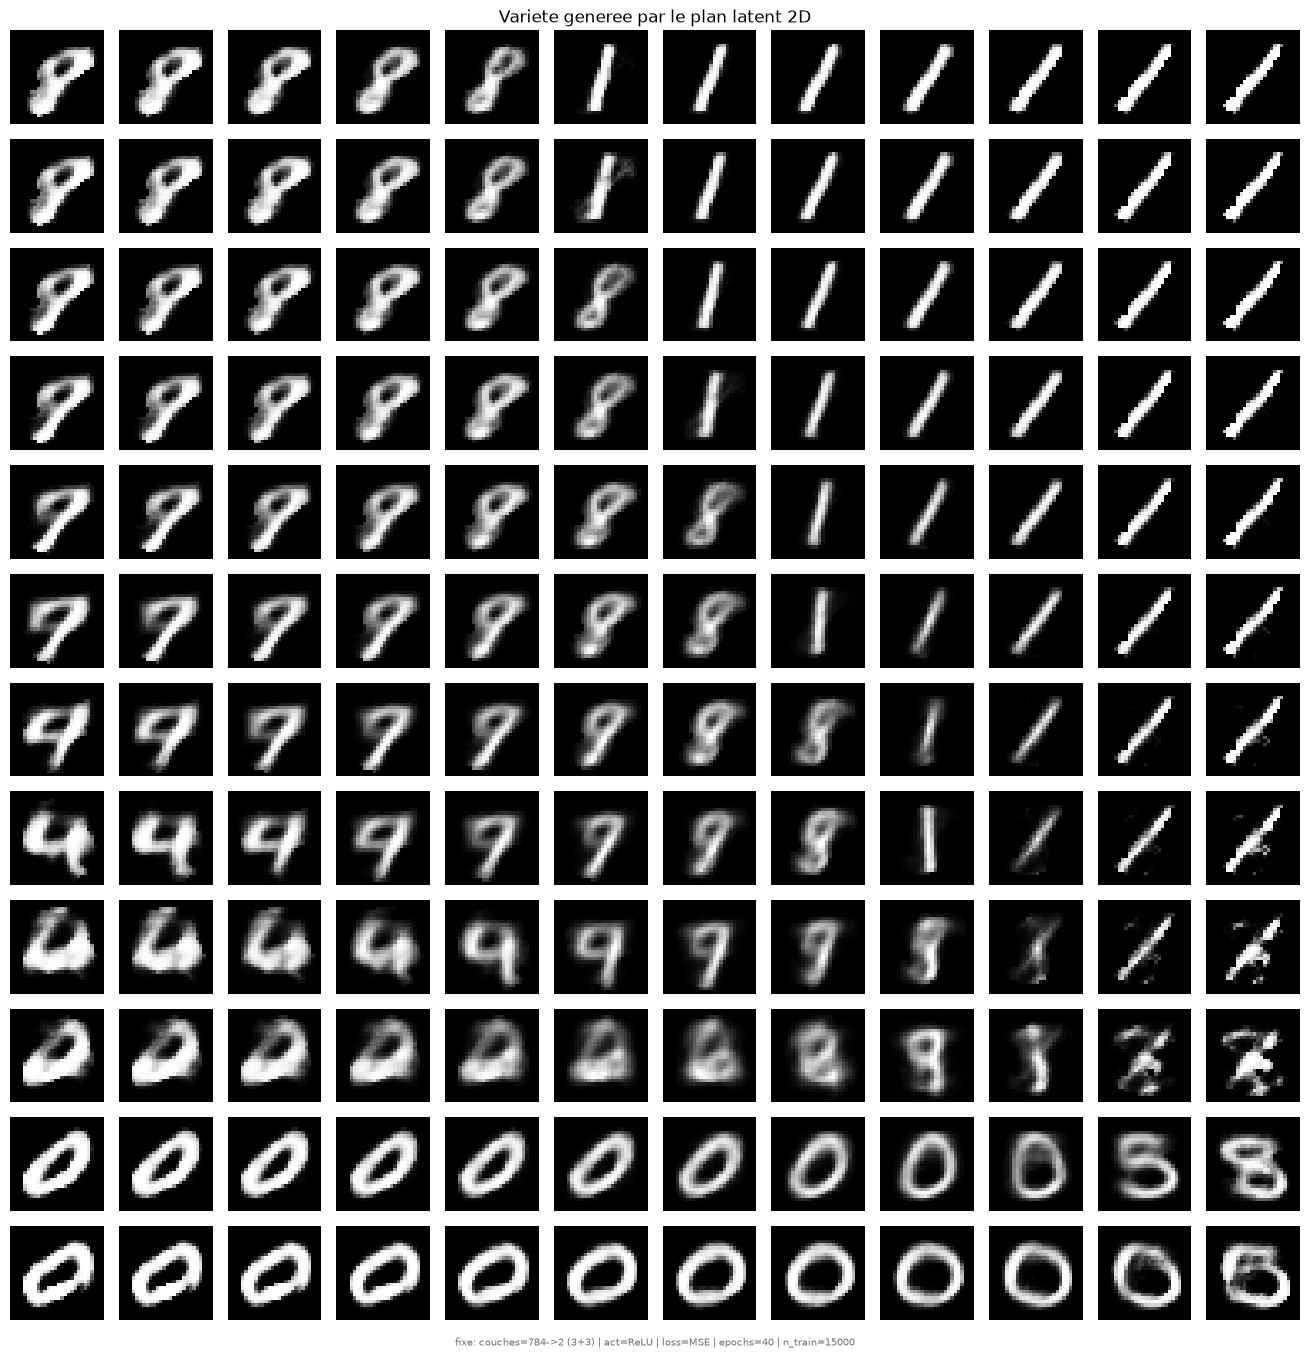

In [8]:
# 1. Echantillonnage gaussien: on ajuste une gaussienne sur les codes, puis on tire dedans.
new_codes = sample_gaussian_latent(mnist_latent.array, n_samples=32)
show_image_grid(mnist_model.decode(Latent(array=new_codes, nature="continuous")),
                MNIST_SHAPE, nrow=4, ncol=8,
                title="Chiffres generes (echantillonnage gaussien)", config=BASE)

# 2. Interpolation: une droite entre deux codes reels.
path = interpolate_latent(mnist_latent.array[0], mnist_latent.array[1], steps=10)
show_image_grid(mnist_model.decode(Latent(array=path, nature="continuous")),
                MNIST_SHAPE, nrow=1, ncol=10,
                title="Interpolation dans l'espace latent", config=BASE)

# 3. Balayage: une grille reguliere sur la boite englobante des codes.
lo, hi = mnist_latent.array.min(axis=0), mnist_latent.array.max(axis=0)
n = 12
xs = np.linspace(lo[0], hi[0], n)
ys = np.linspace(hi[1], lo[1], n)   # de haut en bas: la figure suit l'orientation du scatter
grid = np.array([[x, y] for y in ys for x in xs], dtype=np.float32)
show_image_grid(mnist_model.decode(Latent(array=grid, nature="continuous")),
                MNIST_SHAPE, nrow=n, ncol=n,
                title="Variete generee par le plan latent 2D", config=BASE)

### Experimentation sur les hyper-parametres - courbes

 ReLU | latent= 2 | MSE=0.0563 | total=  369,276 o | ratio=25.48
 ReLU | latent= 8 | MSE=0.0271 | total=  658,712 o | ratio=14.28
 ReLU | latent=16 | MSE=0.0239 | total=  920,688 o | ratio=10.22
 ReLU | latent=32 | MSE=0.0189 | total=1,342,932 o | ratio=7.01
 ReLU | latent=64 | MSE=0.0148 | total=2,076,876 o | ratio=4.53
 Tanh | latent= 2 | MSE=0.0671 | total=  369,276 o | ratio=25.48
 Tanh | latent= 8 | MSE=0.0671 | total=  658,712 o | ratio=14.28
 Tanh | latent=16 | MSE=0.0186 | total=  920,688 o | ratio=10.22
 Tanh | latent=32 | MSE=0.0144 | total=1,342,932 o | ratio=7.01
 Tanh | latent=64 | MSE=0.0107 | total=2,076,876 o | ratio=4.53


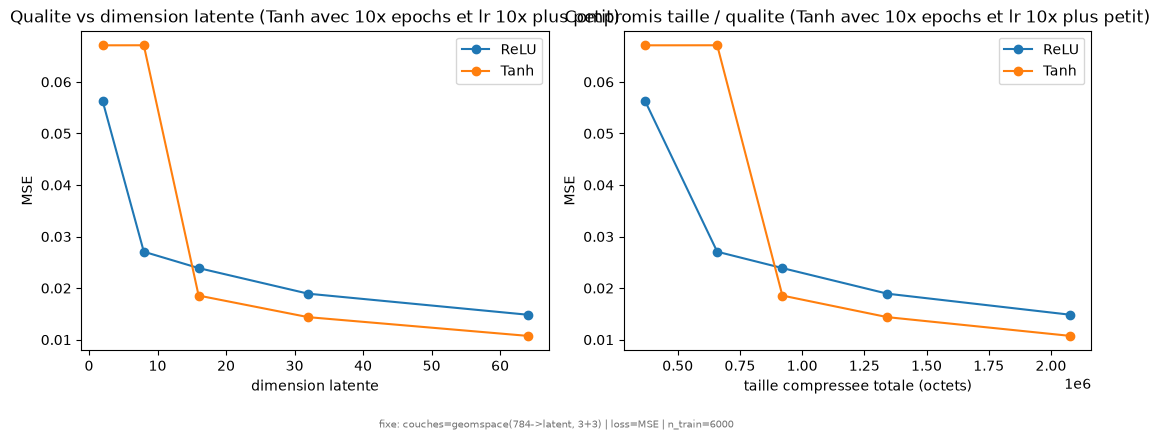

In [26]:
latent_dims = [2, 8, 16, 32, 64]
activations = {"ReLU": nn.ReLU, "Tanh": nn.Tanh}
X_tr, y_tr = subsample_dataset(X_mnist_train, y_mnist_train, 6000, seed=1)

mnist_runs = {}
mnist_results = []
for act_name, act in activations.items():
    for latent_dim in latent_dims:
        # Tanh sature et converge lentement: on lui donne plus d'epochs et un lr plus petit.
        if act_name == "Tanh":
            run = run_experiment(X_tr, X_mnist_eval, 784, latent_dim, act,
                                 EPOCHS_SWEEP * 10, learning_rate=1e-4, latent_activation=act)
        else:
            run = run_experiment(X_tr, X_mnist_eval, 784, latent_dim, act, EPOCHS_SWEEP, learning_rate=1e-3, latent_activation=act)
        mnist_runs[(act_name, latent_dim)] = run
        report = run["report"]
        report.update(latent_dim=latent_dim, activation=act_name)
        mnist_results.append(report)
        print(f"{act_name:>5} | latent={latent_dim:>2} | MSE={report['reconstruction_mse']:.4f} "
              f"| total={report['total_compressed_bytes']:>9,} o | ratio={report['compression_ratio']:.2f}")

SWEEP = note(couches="geomspace(784->latent, 3+3)", loss="MSE", n_train=len(X_tr))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for act_name in activations:
    pts = [r for r in mnist_results if r["activation"] == act_name]
    axes[0].plot([r["latent_dim"] for r in pts], [r["reconstruction_mse"] for r in pts],
                 marker="o", label=act_name)
    axes[1].plot([r["total_compressed_bytes"] for r in pts], [r["reconstruction_mse"] for r in pts],
                 marker="o", label=act_name)
axes[0].set_xlabel("dimension latente"); axes[0].set_ylabel("MSE")
axes[0].set_title("Qualite vs dimension latente (Tanh avec 10x epochs et lr 10x plus petit)"); axes[0].legend()
axes[1].set_xlabel("taille compressee totale (octets)"); axes[1].set_ylabel("MSE")
axes[1].set_title("Compromis taille / qualite (Tanh avec 10x epochs et lr 10x plus petit)"); axes[1].legend()
finish_figure(fig, config=SWEEP)

### Experimentation sur les hyper-parametres - images

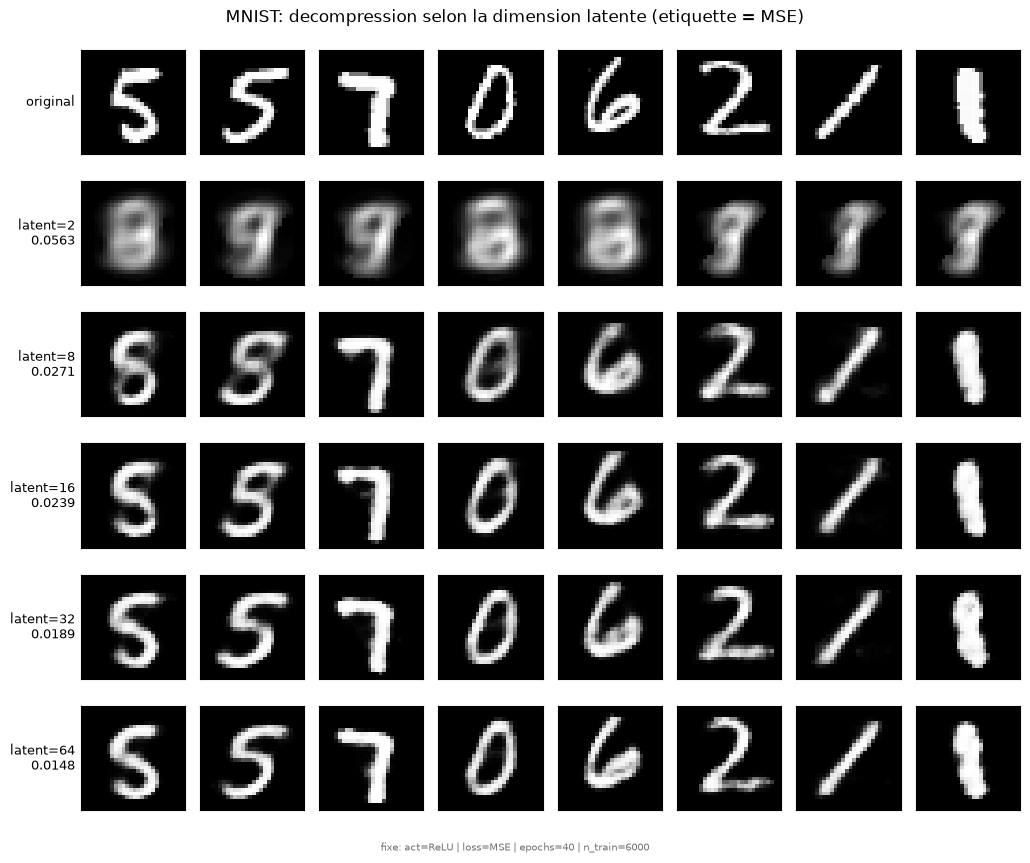

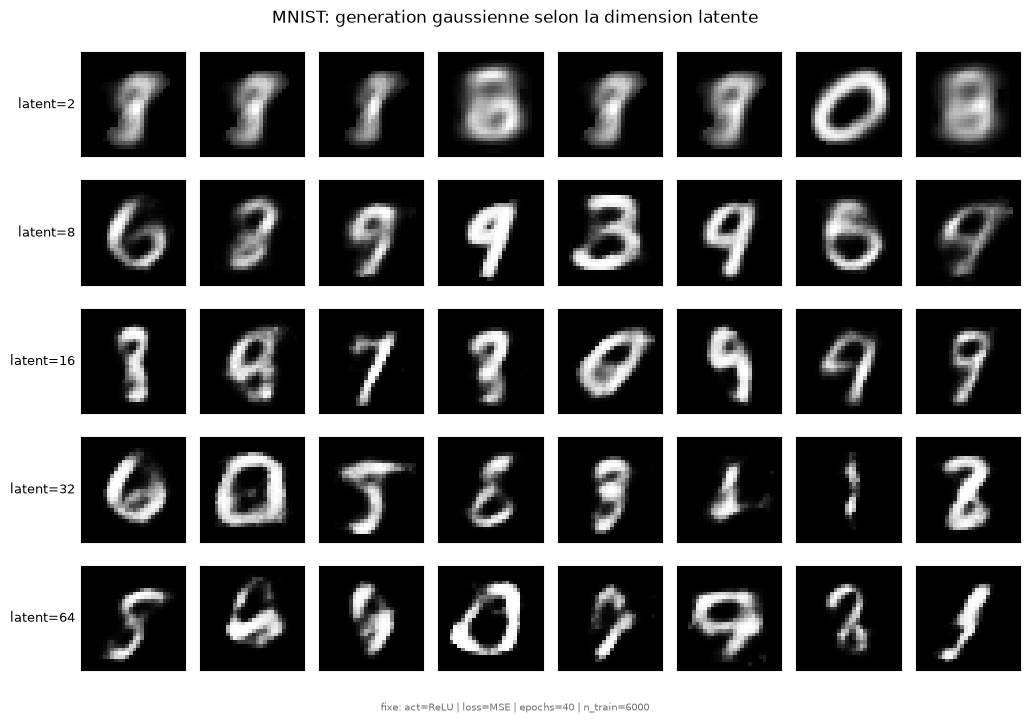

In [27]:
show_labeled_image_rows(
    [X_mnist_eval] + [mnist_runs[("ReLU", d)]["reconstruction"] for d in latent_dims],
    MNIST_SHAPE,
    ["original"] + [f"latent={d}\n{mnist_runs[('ReLU', d)]['report']['reconstruction_mse']:.4f}"
                    for d in latent_dims],
    n=8, title="MNIST: decompression selon la dimension latente (etiquette = MSE)",
    config=note(act="ReLU", loss="MSE", epochs=EPOCHS_SWEEP, n_train=len(X_tr)),
)

show_labeled_image_rows(
    [generate_from_latent_using_gaussian(mnist_runs[("ReLU", d)]["model"],
                                         mnist_runs[("ReLU", d)]["latent"], 8, seed=1)
     for d in latent_dims],
    MNIST_SHAPE, [f"latent={d}" for d in latent_dims],
    n=8, title="MNIST: generation gaussienne selon la dimension latente",
    config=note(act="ReLU", loss="MSE", epochs=EPOCHS_SWEEP, n_train=len(X_tr)),
)

#### Espace latent selon la fonction d'activation


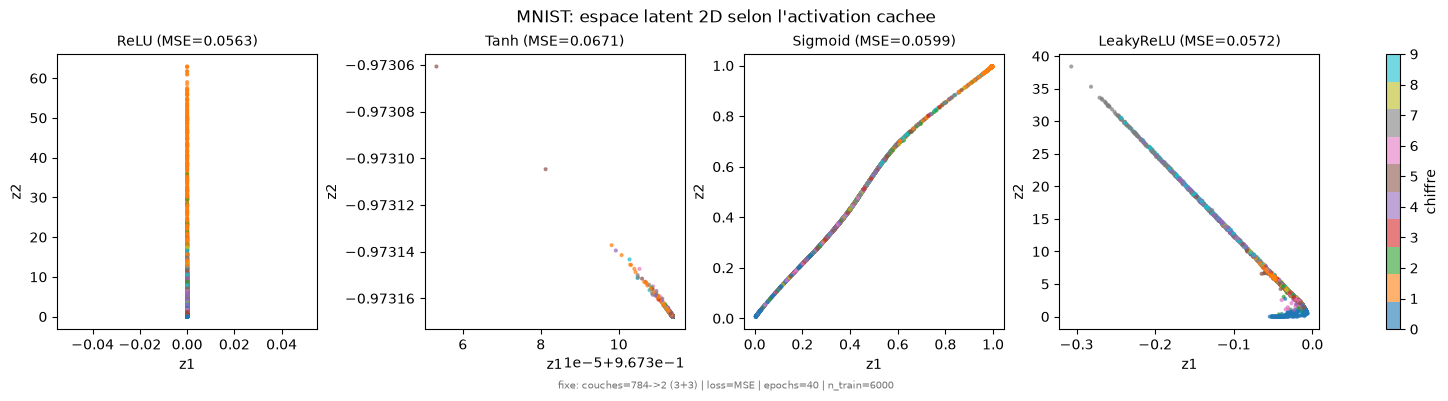

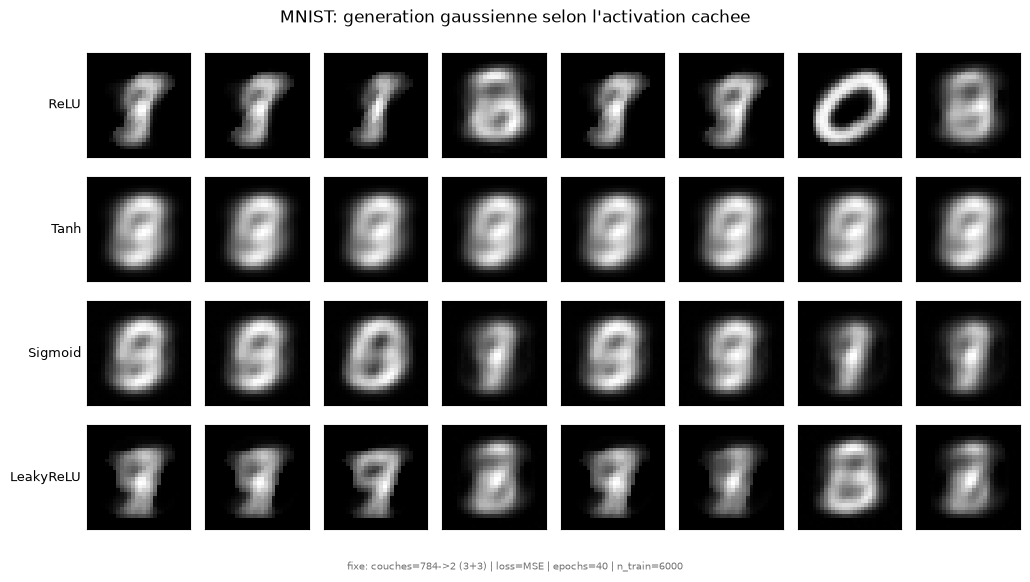

In [28]:
viz_activations = {"ReLU": nn.ReLU, "Tanh": nn.Tanh, "Sigmoid": nn.Sigmoid, "LeakyReLU": nn.LeakyReLU}

for act_name, act in viz_activations.items():
    if (act_name, 2) not in mnist_runs:
        mnist_runs[(act_name, 2)] = run_experiment(X_tr, X_mnist_eval, 784, 2, act, EPOCHS_SWEEP, latent_activation=act)

ACT_NOTE = note(couches="784->2 (3+3)", loss="MSE", epochs=EPOCHS_SWEEP, n_train=len(X_tr))

fig, axes = plt.subplots(1, 4, figsize=(14.4, 3.9), layout="constrained")
for ax, act_name in zip(axes, viz_activations):
    run = mnist_runs[(act_name, 2)]
    codes = run["latent"].array
    scatter = ax.scatter(codes[:, 0], codes[:, 1], c=y_mnist_eval, cmap="tab10", s=4, alpha=0.6)
    ax.set_title(f"{act_name} (MSE={run['report']['reconstruction_mse']:.4f})", fontsize=10)
    ax.set_xlabel("z1"); ax.set_ylabel("z2")
fig.colorbar(scatter, ax=list(axes), label="chiffre")
finish_figure(fig, "MNIST: espace latent 2D selon l'activation cachee", ACT_NOTE, layout=False)

show_labeled_image_rows(
    [generate_from_latent_using_gaussian(mnist_runs[(a, 2)]["model"], mnist_runs[(a, 2)]["latent"], 8, seed=1)
     for a in viz_activations],
    MNIST_SHAPE, list(viz_activations),
    n=8, title="MNIST: generation gaussienne selon l'activation cachee", config=ACT_NOTE,
)

### Variation de la perte et de l'activation de sortie

out_act= Sigmoid | perte=MSE | MSE=0.0158 | pixels nuls:   0.0%
out_act= Sigmoid | perte=L1  | MSE=0.0480 | pixels nuls:   0.0%
out_act= Sigmoid | perte=BCE | MSE=0.0153 | pixels nuls:   0.0%
out_act=    ReLU | perte=MSE | MSE=0.0179 | pixels nuls:  80.4%
out_act=    ReLU | perte=L1  | MSE=0.0318 | pixels nuls:  85.0%
out_act=    ReLU | perte=BCE | INVALIDE (sortie non bornee + BCE)
out_act=  aucune | perte=MSE | MSE=0.0143 | pixels nuls:   0.0%
out_act=  aucune | perte=L1  | MSE=0.0254 | pixels nuls:   0.0%
out_act=  aucune | perte=BCE | INVALIDE (sortie non bornee + BCE)


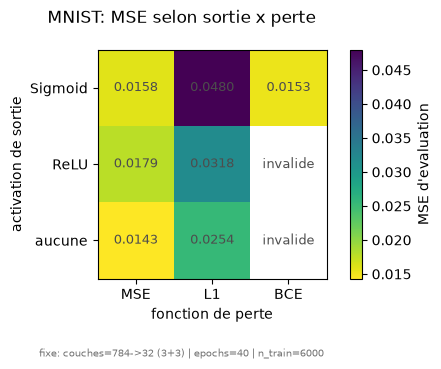

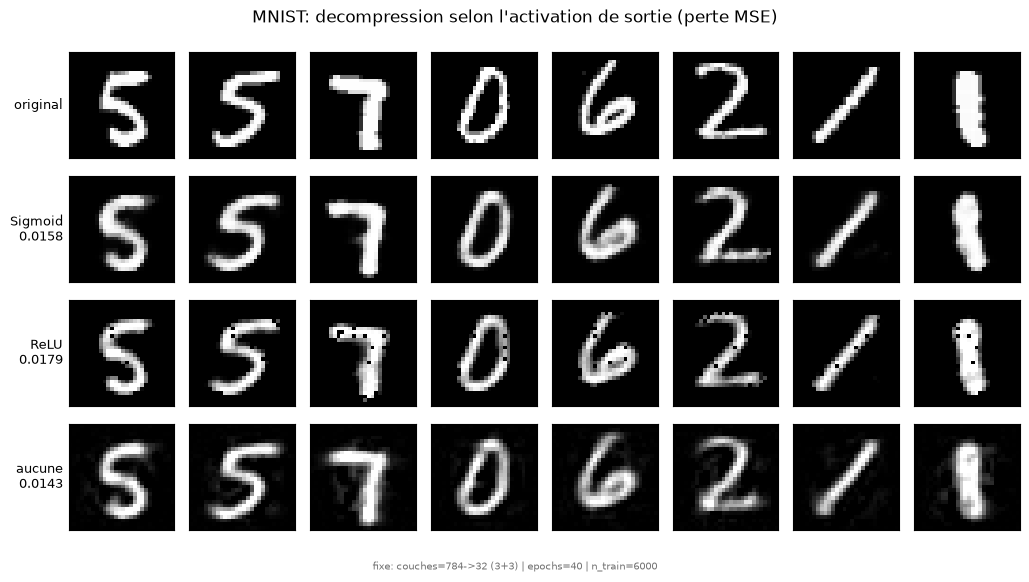

In [29]:
loss_functions = {"MSE": nn.MSELoss, "L1": nn.L1Loss, "BCE": nn.BCELoss}
output_activations = {"Sigmoid": nn.Sigmoid, "ReLU": nn.ReLU, "aucune": None}
# BCE exige des sorties dans [0,1]: on saute ces couples au lieu d'attraper une exception,
# car sur GPU l'assertion de BCELoss corromprait le contexte CUDA pour la suite du notebook.
INVALIDES = {("ReLU", "BCE"), ("aucune", "BCE")}

mnist_out_loss = {}
for out_name, out_act in output_activations.items():
    for loss_name, loss_cls in loss_functions.items():
        if (out_name, loss_name) in INVALIDES:
            print(f"out_act={out_name:>8} | perte={loss_name:<3} | INVALIDE (sortie non bornee + BCE)")
            continue
        run = run_experiment(X_tr, X_mnist_eval, 784, 32, nn.ReLU, EPOCHS_SWEEP,
                             loss_function=loss_cls, output_activation=out_act)
        mnist_out_loss[(out_name, loss_name)] = run
        zeros = 100 * np.mean(run["reconstruction"] == 0)
        print(f"out_act={out_name:>8} | perte={loss_name:<3} "
              f"| MSE={run['report']['reconstruction_mse']:.4f} | pixels nuls: {zeros:5.1f}%")

OUT_NOTE = note(couches="784->32 (3+3)", epochs=EPOCHS_SWEEP, n_train=len(X_tr))

# Carte des MSE. Les cases invalides restent a NaN: imshow les laisse blanches.
matrice = np.full((len(output_activations), len(loss_functions)), np.nan)
for i, out_name in enumerate(output_activations):
    for j, loss_name in enumerate(loss_functions):
        if (out_name, loss_name) in mnist_out_loss:
            matrice[i, j] = mnist_out_loss[(out_name, loss_name)]["report"]["reconstruction_mse"]

fig, ax = plt.subplots(figsize=(5.5, 3.6))
image = ax.imshow(matrice, cmap="viridis_r")
ax.set_xticks(range(3), list(loss_functions)); ax.set_yticks(range(3), list(output_activations))
ax.set_xlabel("fonction de perte"); ax.set_ylabel("activation de sortie")
for i in range(3):
    for j in range(3):
        texte = "invalide" if np.isnan(matrice[i, j]) else f"{matrice[i, j]:.4f}"
        ax.text(j, i, texte, ha="center", va="center", fontsize=9, color="0.3")
fig.colorbar(image, ax=ax, label="MSE d'evaluation")
finish_figure(fig, "MNIST: MSE selon sortie x perte", OUT_NOTE)

show_labeled_image_rows(
    [X_mnist_eval] + [mnist_out_loss[(o, "MSE")]["reconstruction"] for o in output_activations],
    MNIST_SHAPE,
    ["original"] + [f"{o}\n{mnist_out_loss[(o, 'MSE')]['report']['reconstruction_mse']:.4f}"
                    for o in output_activations],
    n=8, title="MNIST: decompression selon l'activation de sortie (perte MSE)",
    config=note(couches="784->32 (3+3)",  epochs=EPOCHS_SWEEP, n_train=len(X_tr)),
)

#### Neurones morts avec ReLU en sortie

Pixels toujours noirs dans les donnees: 149/784

 Sigmoid | MSE=0.0158 | morts bruts=  0 | vraiment morts=  0 | part de l'erreur totale=  0.0%
    ReLU | MSE=0.0179 | morts bruts=409 | vraiment morts=263 | part de l'erreur totale= 42.4%
  aucune | MSE=0.0143 | morts bruts=  0 | vraiment morts=  0 | part de l'erreur totale=  0.0%


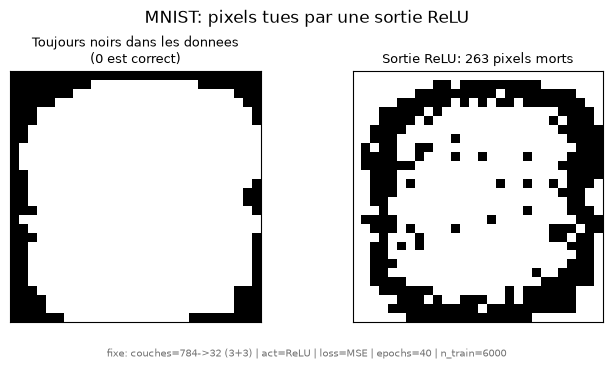

In [30]:
# Un pixel toujours noir dans les DONNEES: y sortir 0 est correct, ce n'est pas une panne.
toujours_noir = (X_mnist_eval == 0).all(axis=0)
print(f"Pixels toujours noirs dans les donnees: {toujours_noir.sum()}/784\n")

for out_name in output_activations:
    run = mnist_out_loss[(out_name, "MSE")]
    mort_partout = (run["reconstruction"] == 0).all(axis=0)
    vraiment_morts = mort_partout & ~toujours_noir      # <- on retire le confondant
    erreur = ((X_mnist_eval - run["reconstruction"]) ** 2).sum(axis=0)
    part = 100 * erreur[vraiment_morts].sum() / erreur.sum() if vraiment_morts.any() else 0.0
    print(f"{out_name:>8} | MSE={run['report']['reconstruction_mse']:.4f} "
          f"| morts bruts={mort_partout.sum():>3} | vraiment morts={vraiment_morts.sum():>3} "
          f"| part de l'erreur totale={part:5.1f}%")

relu_run = mnist_out_loss[("ReLU", "MSE")]
vraiment_morts = (relu_run["reconstruction"] == 0).all(axis=0) & ~toujours_noir

fig, axes = plt.subplots(1, 2, figsize=(7, 3.6))
axes[0].imshow(toujours_noir.reshape(28, 28), cmap="gray_r")
axes[0].set_title("Toujours noirs dans les donnees\n(0 est correct)", fontsize=9)
axes[1].imshow(vraiment_morts.reshape(28, 28), cmap="gray_r")
axes[1].set_title(f"Sortie ReLU: {vraiment_morts.sum()} pixels morts", fontsize=9)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
finish_figure(fig, "MNIST: pixels tues par une sortie ReLU",
              note(couches="784->32 (3+3)", act="ReLU", loss="MSE", epochs=EPOCHS_SWEEP, n_train=len(X_tr)))

## Partie B - shapes

train: (12000, 3072) | eval: (3000, 3072) | classes: ['circle', 'square', 'triangle', 'cross', 'star', 'bar']


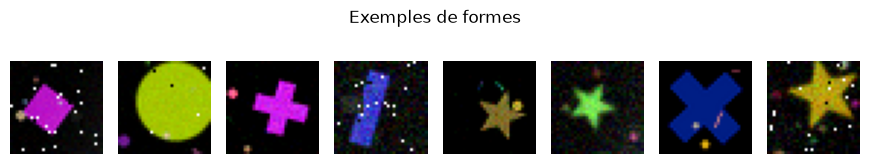

In [31]:
X_shapes_train, y_shapes_train, shape_names = load_shapes_npz(split="train", max_samples=12000)
X_shapes_eval, y_shapes_eval, _ = load_shapes_npz(split="validation", max_samples=3000)
X_shapes_train = X_shapes_train.reshape(len(X_shapes_train), -1)
X_shapes_eval = X_shapes_eval.reshape(len(X_shapes_eval), -1)

SHAPES_SHAPE = (3, 32, 32)
SHAPES_DIM = 3 * 32 * 32
print("train:", X_shapes_train.shape, "| eval:", X_shapes_eval.shape, "| classes:", shape_names)
show_image_grid(X_shapes_eval[:8], SHAPES_SHAPE, nrow=1, ncol=8, title="Exemples de formes")

### Train, compression et decompression

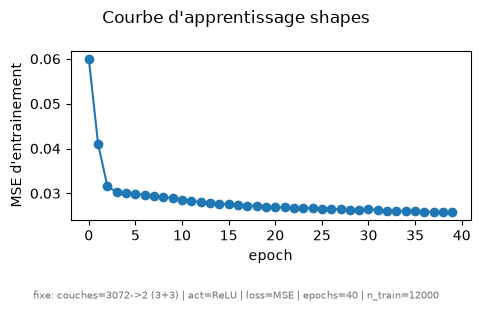

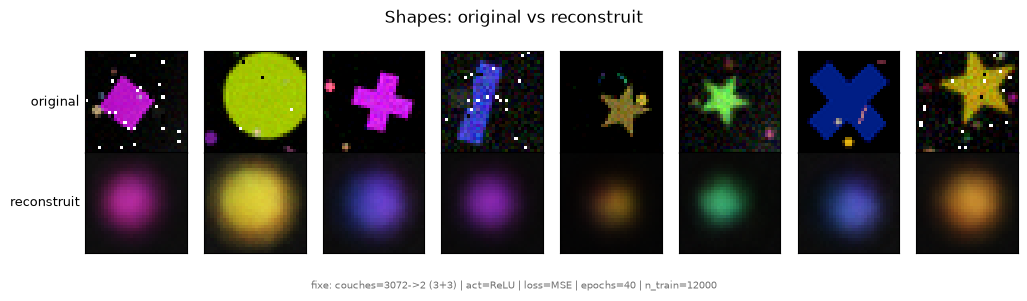

In [32]:
shapes_model = AutoEncoder(
    input_dim=SHAPES_DIM, output_dim=SHAPES_DIM, latent_dim=2,
    encoder_layer_num=3, decoder_layer_num=3, encoder_activation_function=nn.ReLU,
)
shapes_model.fit(X_shapes_train, epochs=EPOCHS, batch_size=BATCH_SIZE)

SHAPES_BASE = note(couches=f"{SHAPES_DIM}->2 (3+3)", act="ReLU", loss="MSE",
                   epochs=EPOCHS, n_train=len(X_shapes_train))

fig = plt.figure(figsize=(5, 3))
plt.plot(shapes_model.loss_history, marker="o")
plt.xlabel("epoch"); plt.ylabel("MSE d'entrainement")
finish_figure(fig, "Courbe d'apprentissage shapes", SHAPES_BASE)

shapes_latent = shapes_model.encode(X_shapes_eval)
shapes_reconstructed = shapes_model.decode(shapes_latent)
show_labeled_image_rows(
    [X_shapes_eval, shapes_reconstructed], SHAPES_SHAPE, ["original", "reconstruit"], n=8,
    title="Shapes: original vs reconstruit", config=SHAPES_BASE,
)

### Metriques de compression

In [33]:
shapes_report = compression_report(shapes_model.get_codebook(), shapes_latent, X_shapes_eval, shapes_reconstructed)
print_compression_report(shapes_report)

per_image_bytes = shapes_latent.n_bytes / len(X_shapes_eval)
print(f"\nMessage par image: {per_image_bytes:.0f} octets contre {X_shapes_eval[0].nbytes} octets en float32.")

           latent_nature: continuous
          codebook_bytes: 3306708
            latent_bytes: 24000
  total_compressed_bytes: 3330708
          original_bytes: 36864000
       compression_ratio: 11.0679
      reconstruction_mse: 0.0266

Message par image: 8 octets contre 12288 octets en float32.


### Espace latent et generation

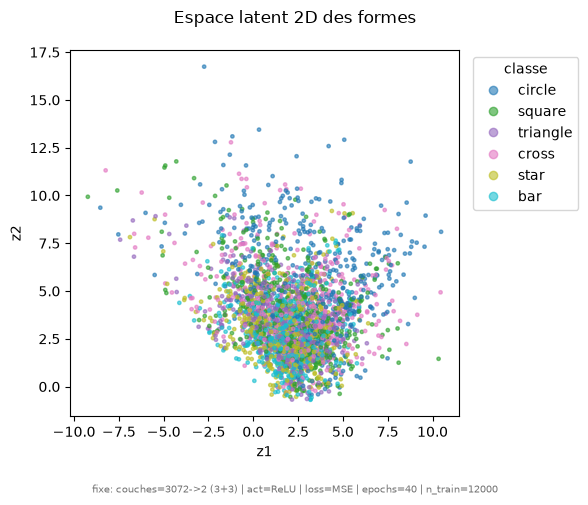

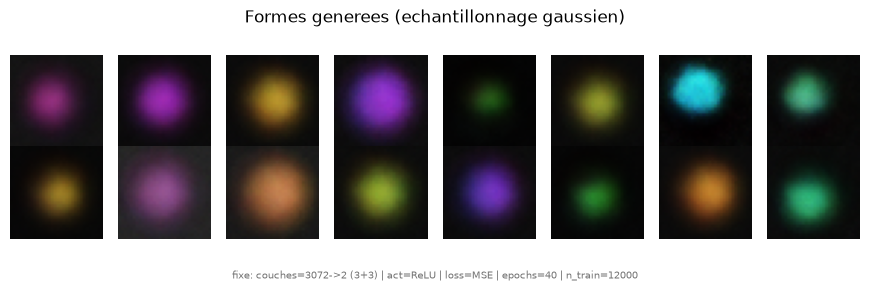

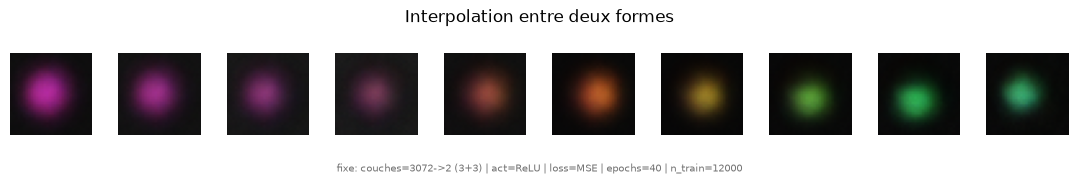

In [34]:
plot_latent_scatter(shapes_latent.array, y_shapes_eval, class_names=shape_names,
                    title="Espace latent 2D des formes", config=SHAPES_BASE)

new_codes = sample_gaussian_latent(shapes_latent.array, n_samples=16)
show_image_grid(shapes_model.decode(Latent(array=new_codes, nature="continuous")),
                SHAPES_SHAPE, nrow=2, ncol=8,
                title="Formes generees (echantillonnage gaussien)", config=SHAPES_BASE)

path = interpolate_latent(shapes_latent.array[0], shapes_latent.array[5], steps=10)
show_image_grid(shapes_model.decode(Latent(array=path, nature="continuous")),
                SHAPES_SHAPE, nrow=1, ncol=10,
                title="Interpolation entre deux formes", config=SHAPES_BASE)

### Experimentation hyper-parametres

latent= 2 | MSE=0.0285 | total=3,330,708 o | ratio=11.07
latent= 8 | MSE=0.0167 | total=5,395,504 o | ratio=6.83
latent=16 | MSE=0.0146 | total=6,945,664 o | ratio=5.31
latent=32 | MSE=0.0131 | total=9,042,480 o | ratio=4.08
latent=64 | MSE=0.0128 | total=12,011,508 o | ratio=3.07


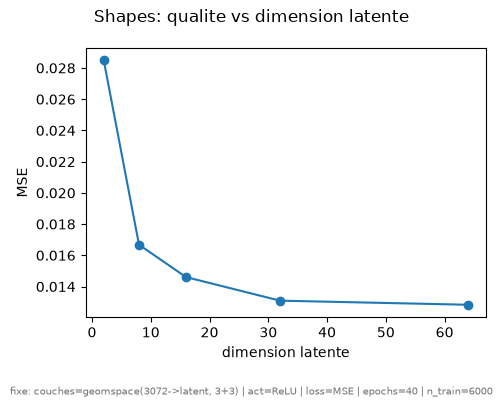

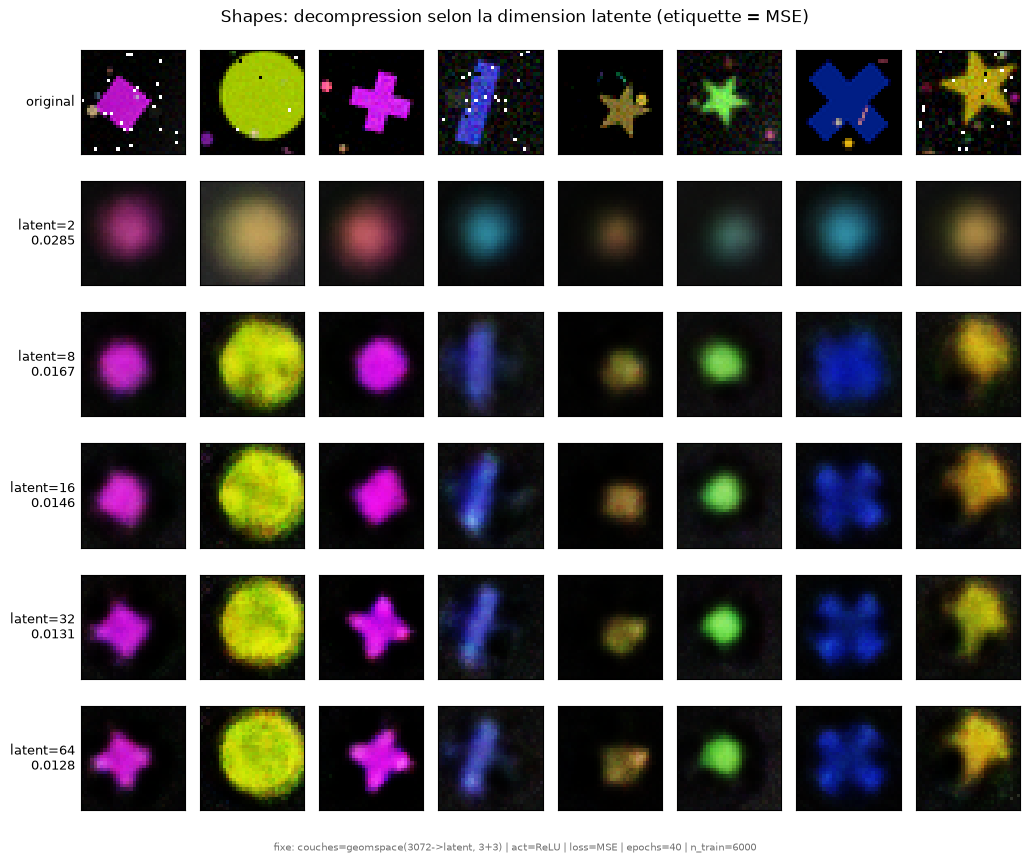

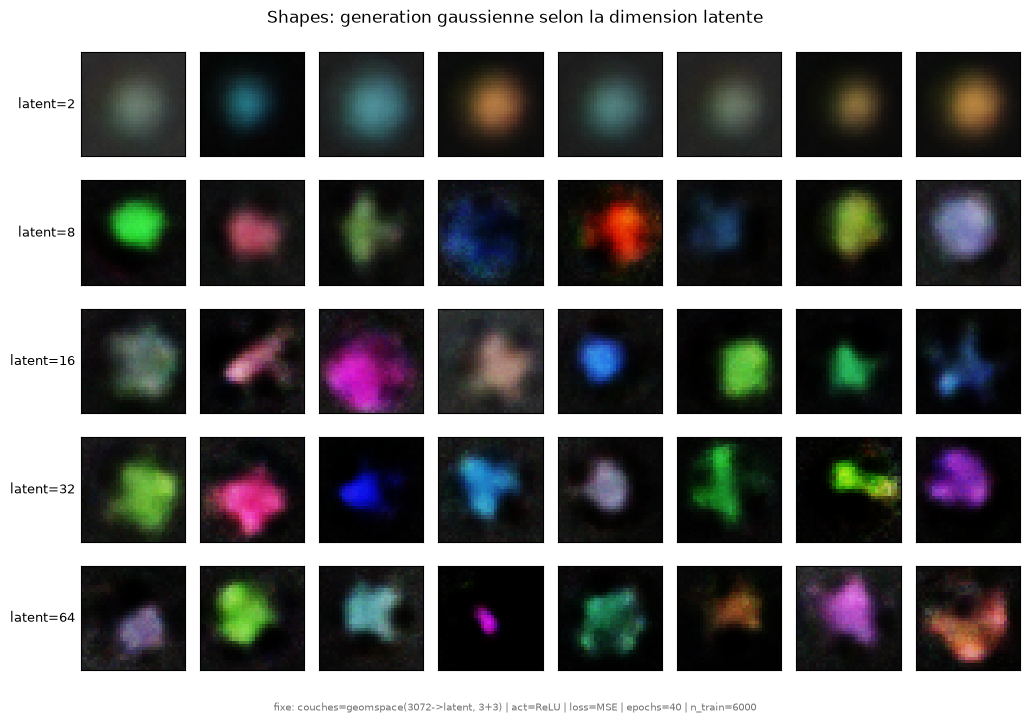

In [35]:
X_shapes_tr, _ = subsample_dataset(X_shapes_train, y_shapes_train, 6000, seed=1)

shapes_runs = {}
shapes_results = []
for latent_dim in latent_dims:
    run = run_experiment(X_shapes_tr, X_shapes_eval, SHAPES_DIM, latent_dim, nn.ReLU, EPOCHS_SWEEP)
    shapes_runs[latent_dim] = run
    report = run["report"]
    report.update(latent_dim=latent_dim)
    shapes_results.append(report)
    print(f"latent={latent_dim:>2} | MSE={report['reconstruction_mse']:.4f} "
          f"| total={report['total_compressed_bytes']:>9,} o | ratio={report['compression_ratio']:.2f}")

SHAPES_SWEEP = note(couches=f"geomspace({SHAPES_DIM}->latent, 3+3)", act="ReLU", loss="MSE",
                    epochs=EPOCHS_SWEEP, n_train=len(X_shapes_tr))

fig = plt.figure(figsize=(5, 4))
plt.plot([r["latent_dim"] for r in shapes_results], [r["reconstruction_mse"] for r in shapes_results], marker="o")
plt.xlabel("dimension latente"); plt.ylabel("MSE")
finish_figure(fig, "Shapes: qualite vs dimension latente", SHAPES_SWEEP)

show_labeled_image_rows(
    [X_shapes_eval] + [shapes_runs[d]["reconstruction"] for d in latent_dims],
    SHAPES_SHAPE,
    ["original"] + [f"latent={d}\n{shapes_runs[d]['report']['reconstruction_mse']:.4f}" for d in latent_dims],
    n=8, title="Shapes: decompression selon la dimension latente (etiquette = MSE)",
    config=SHAPES_SWEEP,
)

show_labeled_image_rows(
    [generate_from_latent_using_gaussian(shapes_runs[d]["model"], shapes_runs[d]["latent"], 8, seed=1)
     for d in latent_dims],
    SHAPES_SHAPE, [f"latent={d}" for d in latent_dims],
    n=8, title="Shapes: generation gaussienne selon la dimension latente", config=SHAPES_SWEEP,
)

### Variation de la fonction de perte
MSE, L1, BCE

perte=MSE | MSE=0.0280
perte=L1  | MSE=0.0344
perte=BCE | MSE=0.0280


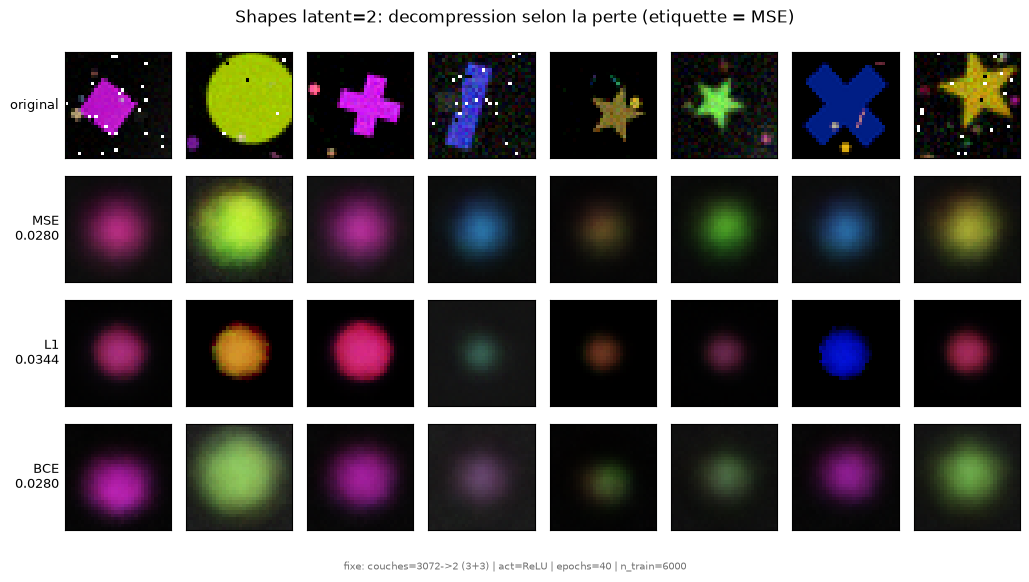

In [37]:
SHAPES_LOSS_LATENT = 2

shapes_loss_runs = {}
for name, loss_cls in loss_functions.items():
    run = run_experiment(X_shapes_tr, X_shapes_eval, SHAPES_DIM, SHAPES_LOSS_LATENT, nn.ReLU,
                         EPOCHS_SWEEP, loss_function=loss_cls)
    shapes_loss_runs[name] = run
    print(f"perte={name:<3} | MSE={run['report']['reconstruction_mse']:.4f}")

SHAPES_LOSS = note(couches=f"{SHAPES_DIM}->{SHAPES_LOSS_LATENT} (3+3)", act="ReLU",
                   epochs=EPOCHS_SWEEP, n_train=len(X_shapes_tr))

show_labeled_image_rows(
    [X_shapes_eval] + [shapes_loss_runs[n]["reconstruction"] for n in loss_functions],
    SHAPES_SHAPE,
    ["original"] + [f"{n}\n{shapes_loss_runs[n]['report']['reconstruction_mse']:.4f}"
                    for n in loss_functions],
    n=8, title=f"Shapes latent={SHAPES_LOSS_LATENT}: decompression selon la perte (etiquette = MSE)",
    config=SHAPES_LOSS,
)

perte=MSE | MSE=0.0130
perte=L1  | MSE=0.0646
perte=BCE | MSE=0.0133


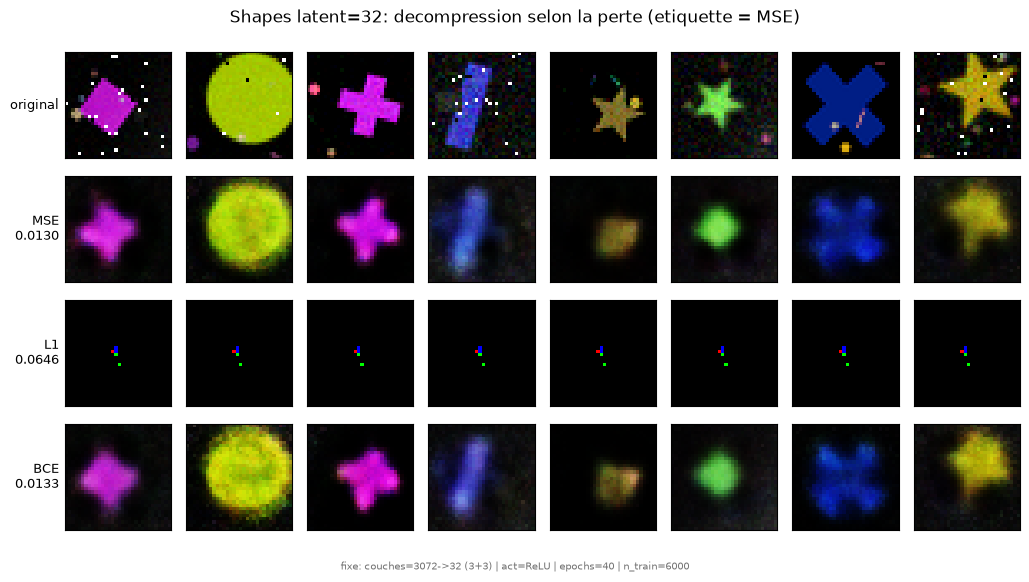

In [ ]:
SHAPES_LOSS_LATENT = 32

shapes_loss_runs = {}
for name, loss_cls in loss_functions.items():
    run = run_experiment(X_shapes_tr, X_shapes_eval, SHAPES_DIM, SHAPES_LOSS_LATENT, nn.ReLU,
                         EPOCHS_SWEEP, loss_function=loss_cls)
    shapes_loss_runs[name] = run
    print(f"perte={name:<3} | MSE={run['report']['reconstruction_mse']:.4f}")

SHAPES_LOSS = note(couches=f"{SHAPES_DIM}->{SHAPES_LOSS_LATENT} (3+3)", act="ReLU",
                   epochs=EPOCHS_SWEEP, n_train=len(X_shapes_tr))

show_labeled_image_rows(
    [X_shapes_eval] + [shapes_loss_runs[n]["reconstruction"] for n in loss_functions],
    SHAPES_SHAPE,
    ["original"] + [f"{n}\n{shapes_loss_runs[n]['report']['reconstruction_mse']:.4f}"
                    for n in loss_functions],
    n=8, title=f"Shapes latent={SHAPES_LOSS_LATENT}: decompression selon la perte (etiquette = MSE)",
    config=SHAPES_LOSS,
)

## Experimentation - nombre d'epochs

Chaque budget entraine un modele independant: `fit` reinstancie son optimiseur Adam a chaque
appel, donc 4 x 20 epochs ne valent pas 80. L'ecart entre MSE d'entrainement et MSE d'evaluation
dit le regime: les deux hautes et confondues = sous-apprentissage.

epochs=  5 | MSE train=0.0658 | MSE eval=0.0655
epochs= 10 | MSE train=0.0541 | MSE eval=0.0534
epochs= 20 | MSE train=0.0542 | MSE eval=0.0538
epochs= 40 | MSE train=0.0481 | MSE eval=0.0485
epochs= 80 | MSE train=0.0433 | MSE eval=0.0452


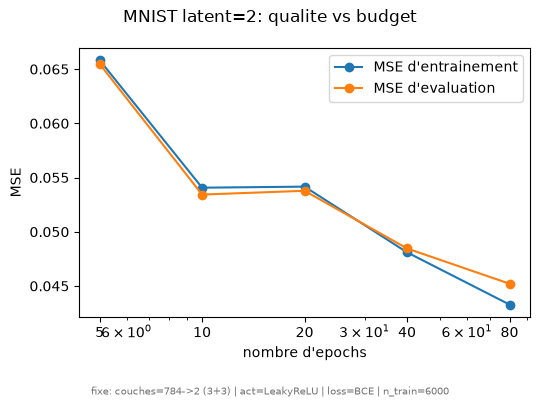

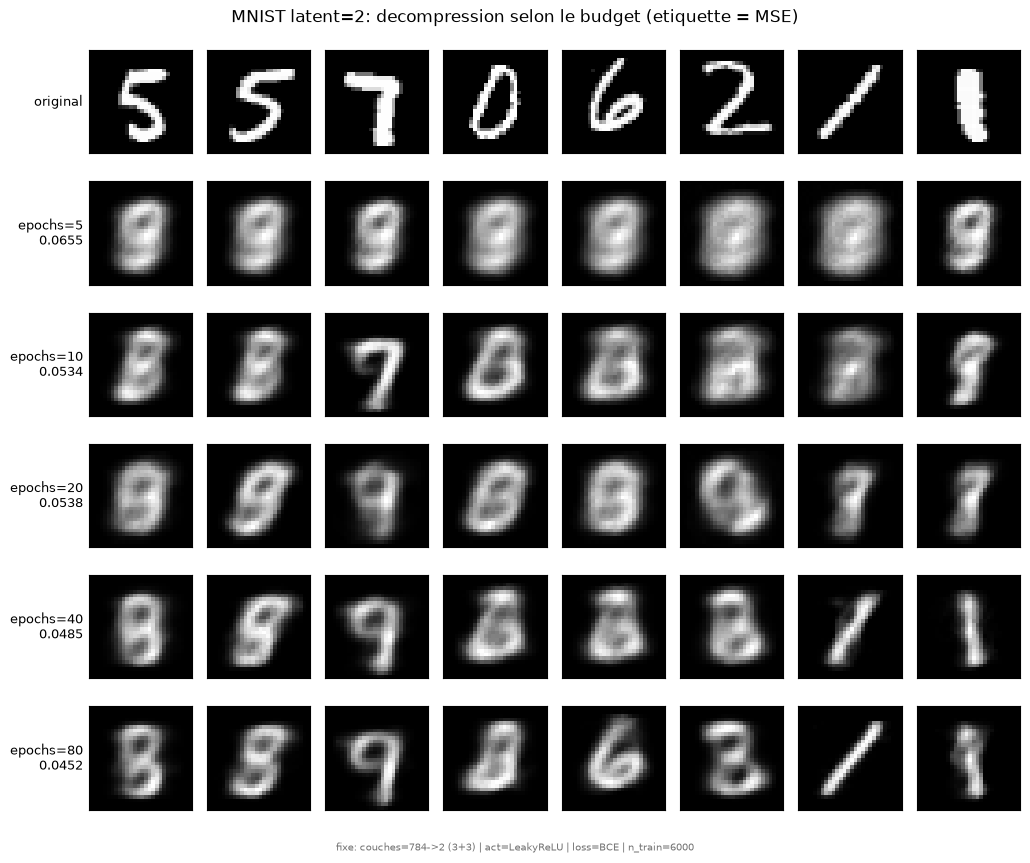

In [ ]:
EPOCH_BUDGETS = [5, 10, 20, 40, 80]
EPOCH_EXP_LATENT = 2

epoch_runs = {}
for budget in EPOCH_BUDGETS:
    run = run_experiment(X_tr, X_mnist_eval, 784, EPOCH_EXP_LATENT, nn.LeakyReLU, budget,
                         loss_function=nn.BCELoss)
    # MSE d'entrainement: comparable a la MSE d'evaluation, contrairement a la perte BCE.
    train_rec = run["model"].decode(run["model"].encode(X_tr))
    run["train_mse"] = float(np.mean((X_tr - train_rec) ** 2))
    epoch_runs[budget] = run
    print(f"epochs={budget:>3} | MSE train={run['train_mse']:.4f} "
          f"| MSE eval={run['report']['reconstruction_mse']:.4f}")

EPOCH_NOTE = note(couches=f"784->{EPOCH_EXP_LATENT} (3+3)", act="LeakyReLU", loss="BCE",
                  n_train=len(X_tr))

fig = plt.figure(figsize=(5.5, 4))
plt.plot(EPOCH_BUDGETS, [epoch_runs[b]["train_mse"] for b in EPOCH_BUDGETS],
         marker="o", label="MSE d'entrainement")
plt.plot(EPOCH_BUDGETS, [epoch_runs[b]["report"]["reconstruction_mse"] for b in EPOCH_BUDGETS],
         marker="o", label="MSE d'evaluation")
plt.xscale("log"); plt.xticks(EPOCH_BUDGETS, [str(b) for b in EPOCH_BUDGETS])
plt.xlabel("nombre d'epochs"); plt.ylabel("MSE"); plt.legend()
finish_figure(fig, f"MNIST latent={EPOCH_EXP_LATENT}: qualite vs budget", EPOCH_NOTE)

show_labeled_image_rows(
    [X_mnist_eval] + [epoch_runs[b]["reconstruction"] for b in EPOCH_BUDGETS],
    MNIST_SHAPE,
    ["original"] + [f"epochs={b}\n{epoch_runs[b]['report']['reconstruction_mse']:.4f}"
                    for b in EPOCH_BUDGETS],
    n=8, title=f"MNIST latent={EPOCH_EXP_LATENT}: decompression selon le budget (etiquette = MSE)",
    config=EPOCH_NOTE,
)

epochs=  5 | MSE train=0.0501 | MSE eval=0.0492
epochs= 10 | MSE train=0.0479 | MSE eval=0.0471
epochs= 20 | MSE train=0.0379 | MSE eval=0.0378
epochs= 40 | MSE train=0.0330 | MSE eval=0.0336
epochs= 80 | MSE train=0.0314 | MSE eval=0.0333


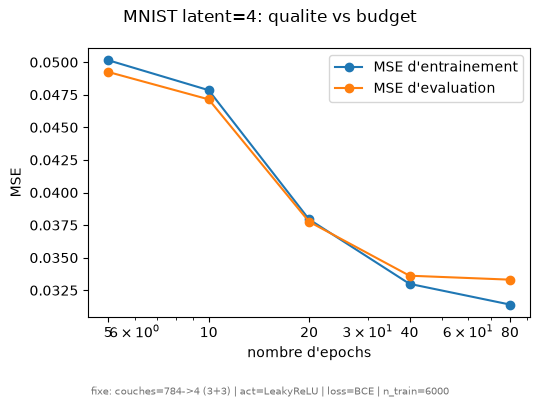

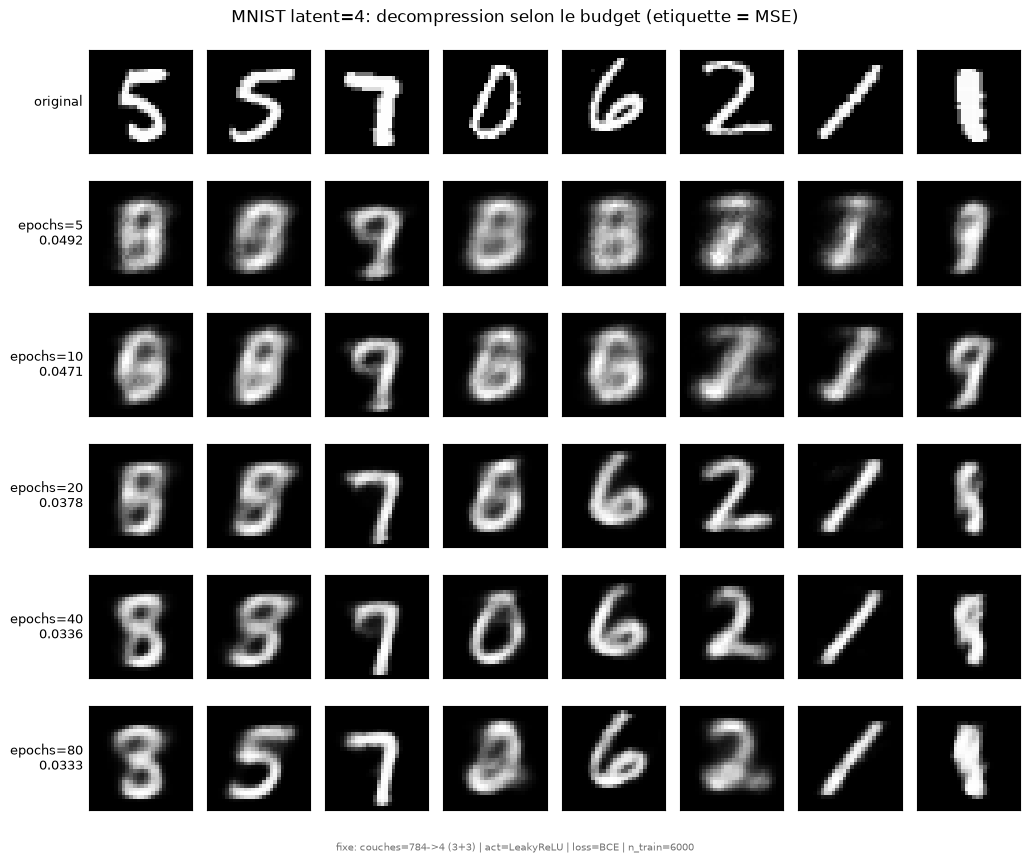

In [ ]:
EPOCH_BUDGETS = [5, 10, 20, 40, 80]
EPOCH_EXP_LATENT = 4

epoch_runs = {}
for budget in EPOCH_BUDGETS:
    run = run_experiment(X_tr, X_mnist_eval, 784, EPOCH_EXP_LATENT, nn.LeakyReLU, budget,
                         loss_function=nn.BCELoss)
    # MSE d'entrainement: comparable a la MSE d'evaluation, contrairement a la perte BCE.
    train_rec = run["model"].decode(run["model"].encode(X_tr))
    run["train_mse"] = float(np.mean((X_tr - train_rec) ** 2))
    epoch_runs[budget] = run
    print(f"epochs={budget:>3} | MSE train={run['train_mse']:.4f} "
          f"| MSE eval={run['report']['reconstruction_mse']:.4f}")

EPOCH_NOTE = note(couches=f"784->{EPOCH_EXP_LATENT} (3+3)", act="LeakyReLU", loss="BCE",
                  n_train=len(X_tr))

fig = plt.figure(figsize=(5.5, 4))
plt.plot(EPOCH_BUDGETS, [epoch_runs[b]["train_mse"] for b in EPOCH_BUDGETS],
         marker="o", label="MSE d'entrainement")
plt.plot(EPOCH_BUDGETS, [epoch_runs[b]["report"]["reconstruction_mse"] for b in EPOCH_BUDGETS],
         marker="o", label="MSE d'evaluation")
plt.xscale("log"); plt.xticks(EPOCH_BUDGETS, [str(b) for b in EPOCH_BUDGETS])
plt.xlabel("nombre d'epochs"); plt.ylabel("MSE"); plt.legend()
finish_figure(fig, f"MNIST latent={EPOCH_EXP_LATENT}: qualite vs budget", EPOCH_NOTE)

show_labeled_image_rows(
    [X_mnist_eval] + [epoch_runs[b]["reconstruction"] for b in EPOCH_BUDGETS],
    MNIST_SHAPE,
    ["original"] + [f"epochs={b}\n{epoch_runs[b]['report']['reconstruction_mse']:.4f}"
                    for b in EPOCH_BUDGETS],
    n=8, title=f"MNIST latent={EPOCH_EXP_LATENT}: decompression selon le budget (etiquette = MSE)",
    config=EPOCH_NOTE,
)

## Experimentation - activation du code latent

Par defaut le code latent est la sortie brute d'un `nn.Linear`, donc non borne. `latent_activation`
permet de le borner: ReLU le confine au quadrant positif, Sigmoid l'ecrase dans (0,1).

A regarder surtout sur la generation: `sample_gaussian_latent` tire dans une gaussienne non bornee,
donc face a un nuage borne une bonne part des tirages tombe hors de ce que l'encodeur peut produire.

lineaire | MSE=0.0477 | z1 dans [-20.97, +10.96] | codes exactement nuls: 0.0%
    ReLU | MSE=0.0501 | z1 dans [+0.00, +9.78] | codes exactement nuls: 3.0%
 Sigmoid | MSE=0.0671 | z1 dans [+1.00, +1.00] | codes exactement nuls: 0.0%


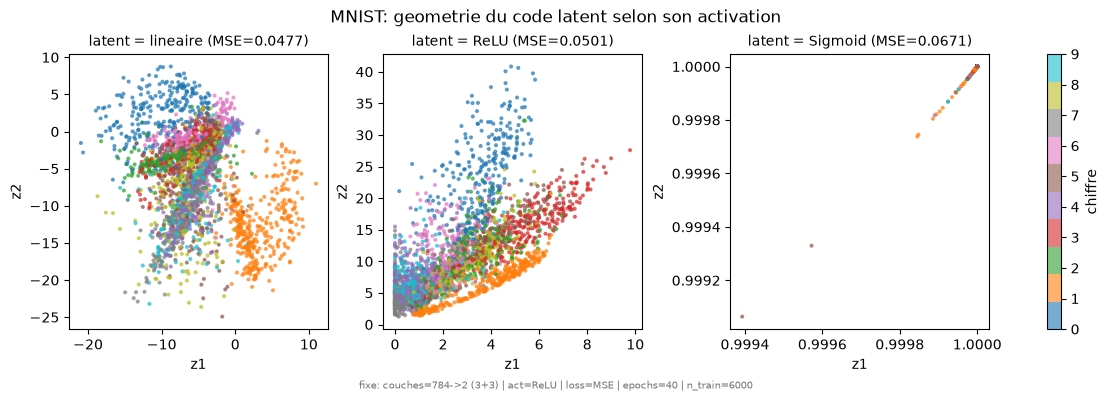

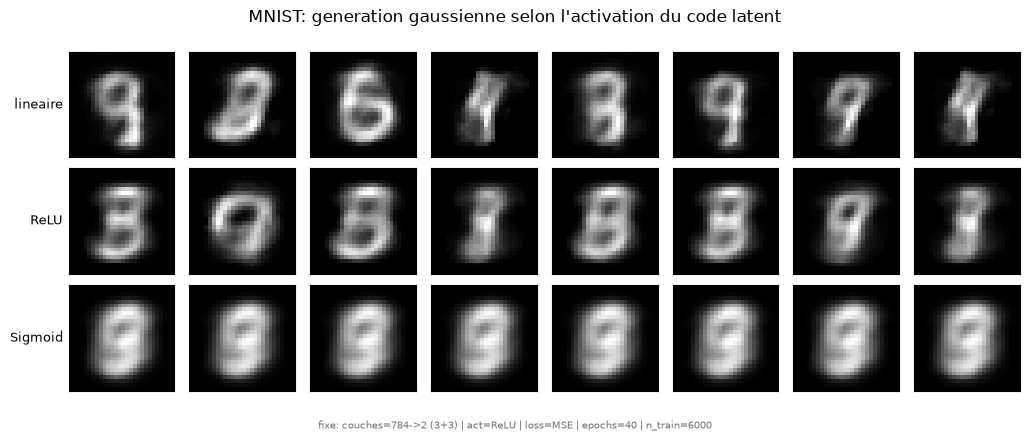

In [ ]:
latent_activations = {"lineaire": None, "ReLU": nn.ReLU, "Sigmoid": nn.Sigmoid}

latent_act_runs = {}
for act_name, act in latent_activations.items():
    run = run_experiment(X_tr, X_mnist_eval, 784, 2, nn.ReLU, EPOCHS_SWEEP, latent_activation=act)
    codes = run["latent"].array
    latent_act_runs[act_name] = run
    print(f"{act_name:>8} | MSE={run['report']['reconstruction_mse']:.4f} "
          f"| z1 dans [{codes[:, 0].min():+.2f}, {codes[:, 0].max():+.2f}] "
          f"| codes exactement nuls: {100 * np.mean(codes == 0):.1f}%")

LAT_NOTE = note(couches="784->2 (3+3)", act="ReLU", loss="MSE", epochs=EPOCHS_SWEEP, n_train=len(X_tr))

fig, axes = plt.subplots(1, 3, figsize=(11, 3.9), layout="constrained")
for ax, act_name in zip(axes, latent_activations):
    run = latent_act_runs[act_name]
    codes = run["latent"].array
    scatter = ax.scatter(codes[:, 0], codes[:, 1], c=y_mnist_eval, cmap="tab10", s=4, alpha=0.6)
    ax.set_title(f"latent = {act_name} (MSE={run['report']['reconstruction_mse']:.4f})", fontsize=10)
    ax.set_xlabel("z1"); ax.set_ylabel("z2")
fig.colorbar(scatter, ax=list(axes), label="chiffre")
finish_figure(fig, "MNIST: geometrie du code latent selon son activation", LAT_NOTE, layout=False)

show_labeled_image_rows(
    [generate_from_latent_using_gaussian(latent_act_runs[a]["model"], latent_act_runs[a]["latent"], 8, seed=1)
     for a in latent_activations],
    MNIST_SHAPE, list(latent_activations),
    n=8, title="MNIST: generation gaussienne selon l'activation du code latent", config=LAT_NOTE,
)

## Experimentation - profondeur du reseau a latent fixe

Latent fixe a 2, profondeur de 1 a 6. A latent fixe le message reste a 8 octets par image, mais le
codebook (= les poids du decodeur) grossit avec la profondeur: c'est lui qui fait s'effondrer le
ratio de compression.

A d=1 l'encodeur est purement lineaire: `build_layers` ne pose une activation qu'*entre* les
couches, et il n'y en a qu'une. C'est essentiellement une PCA.

3 graines et des barres d'erreur, parce qu'une seule graine fabrique des creux qui n'existent pas.

d=1 | MSE=0.0629 +/- 0.0007 | codebook=    9,408 o | ratio=281.61
d=2 | MSE=0.0514 +/- 0.0008 | codebook=  125,908 o | ratio= 62.76
d=3 | MSE=0.0483 +/- 0.0013 | codebook=  345,276 o | ratio= 25.48
d=4 | MSE=0.0507 +/- 0.0033 | codebook=  584,732 o | ratio= 15.46
d=5 | MSE=0.0597 +/- 0.0106 | codebook=  821,532 o | ratio= 11.13
d=6 | MSE=0.0538 +/- 0.0099 | codebook=1,054,144 o | ratio=  8.73

Meilleure profondeur: d=3


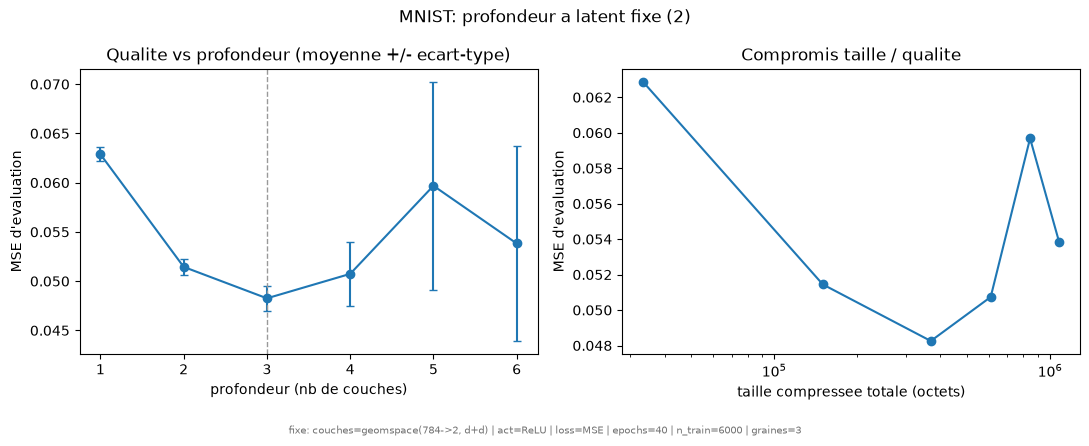

In [ ]:
DEPTHS = [1, 2, 3, 4, 5, 6]
SEEDS = [0, 1, 2]

depth_results = {}
for depth in DEPTHS:
    mses = []
    for seed in SEEDS:
        torch.manual_seed(seed)
        run = run_experiment(X_tr, X_mnist_eval, 784, 2, nn.ReLU, EPOCHS_SWEEP, n_layers=depth)
        mses.append(run["report"]["reconstruction_mse"])
    depth_results[depth] = {
        "mse": float(np.mean(mses)), "ecart": float(np.std(mses)),
        "codebook": run["report"]["codebook_bytes"],
        "total": run["report"]["total_compressed_bytes"],
        "ratio": run["report"]["compression_ratio"],
    }
    r = depth_results[depth]
    print(f"d={depth} | MSE={r['mse']:.4f} +/- {r['ecart']:.4f} "
          f"| codebook={r['codebook']:>9,} o | ratio={r['ratio']:6.2f}")

meilleure = min(DEPTHS, key=lambda d: depth_results[d]["mse"])
print(f"\nMeilleure profondeur: d={meilleure}")

DEPTH_NOTE = note(couches="geomspace(784->2, d+d)", act="ReLU", loss="MSE",
                  epochs=EPOCHS_SWEEP, n_train=len(X_tr), graines=len(SEEDS))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].errorbar(DEPTHS, [depth_results[d]["mse"] for d in DEPTHS],
                 yerr=[depth_results[d]["ecart"] for d in DEPTHS], marker="o", capsize=3)
axes[0].axvline(meilleure, color="0.6", linestyle="--", linewidth=1)
axes[0].set_xlabel("profondeur (nb de couches)"); axes[0].set_ylabel("MSE d'evaluation")
axes[0].set_title("Qualite vs profondeur (moyenne +/- ecart-type)")
axes[1].plot([depth_results[d]["total"] for d in DEPTHS], [depth_results[d]["mse"] for d in DEPTHS], marker="o")
axes[1].set_xscale("log")
axes[1].set_xlabel("taille compressee totale (octets)"); axes[1].set_ylabel("MSE d'evaluation")
axes[1].set_title("Compromis taille / qualite")
finish_figure(fig, "MNIST: profondeur a latent fixe (2)", DEPTH_NOTE)

## Reponses aux questions du projet

1. Nature de l'espace latent.

Il est continu: encode renvoie un Latent de nature "continuous", c'est-a-dire un vecteur de reels (float32) dense. N'importe quel point de l'espace peut etre decode, ce qui rend possibles l'interpolation et l'echantillonnage. Cela contraste avec K-Means, dont l'espace latent est discret (un indice de cluster parmi K).

2. Codebook.

Le codebook renvoye par get_codebook regroupe les poids du decodeur. C'est le dictionnaire partage: l'emetteur et le recepteur doivent tous deux en disposer pour reconstruire. Concretement, l'emetteur compresse avec l'encodeur et n'envoie que le code latent; le recepteur applique le decodeur (le codebook) a ce code. Le codebook est un cout fixe, paye une seule fois et amorti sur toutes les images.

3. Qualite de reconstruction.

Mesuree par la MSE de compression_report (voir les tableaux ci-dessus) et visible sur les grilles original vs reconstruit. Elle s'ameliore quand la dimension latente augmente, au prix d'un message plus gros: c'est le compromis illustre par les courbes d'experimentation. Elle depend aussi de la fonction de perte d'entrainement (MSE, L1, BCE).

4. Code byte (taille du message).

Le message transmis par image est le code latent: dimension_latente x 4 octets (float32), soit par exemple 128 octets pour une dimension latente de 32. La taille totale pour un lot est latent_bytes dans compression_report; le codebook s'y ajoute une seule fois, independamment du nombre d'images.